In [65]:
import sys
sys.path.insert(0, "src")

In [66]:
import json
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import requests
import seaborn as sns
from shapely.geometry import LineString, Point
from profiles import Profile

In [67]:
with open("artifacts/filtered_profiles.json") as file:
    profles_json = json.load(file)
filtered_profiles = [Profile.model_validate(profile_json) for profile_json in profles_json]

In [68]:
TIGER_DIR = Path("artifacts/tiger")
TIGER_DIR.mkdir(parents = True, exist_ok = True)
STATE_FIPS = {"11", "24", "51"}

TIGER_FILES = {
    "state": "https://www2.census.gov/geo/tiger/TIGER2024/STATE/tl_2024_us_state.zip",
    "county": "https://www2.census.gov/geo/tiger/TIGER2024/COUNTY/tl_2024_us_county.zip"
}

def fetch_tiger(name: str, url: str) -> Path:
    path = TIGER_DIR / f"{name}.zip"
    if path.exists():
        return path
    response = requests.get(url, stream = True, timeout = 120)
    response.raise_for_status()
    with open(path, "wb") as file:
        for chunk in response.iter_content(chunk_size = 1 << 16):
            file.write(chunk)
    return path

state_path = fetch_tiger("state", TIGER_FILES["state"])
county_path = fetch_tiger("county", TIGER_FILES["county"])

states_gdf = gpd.read_file(f"zip://{state_path}").to_crs("EPSG:4326")
states_gdf = states_gdf[states_gdf["STATEFP"].isin(STATE_FIPS)]

counties_gdf = gpd.read_file(f"zip://{county_path}").to_crs("EPSG:4326")
counties_gdf = counties_gdf[counties_gdf["STATEFP"].isin(STATE_FIPS)]

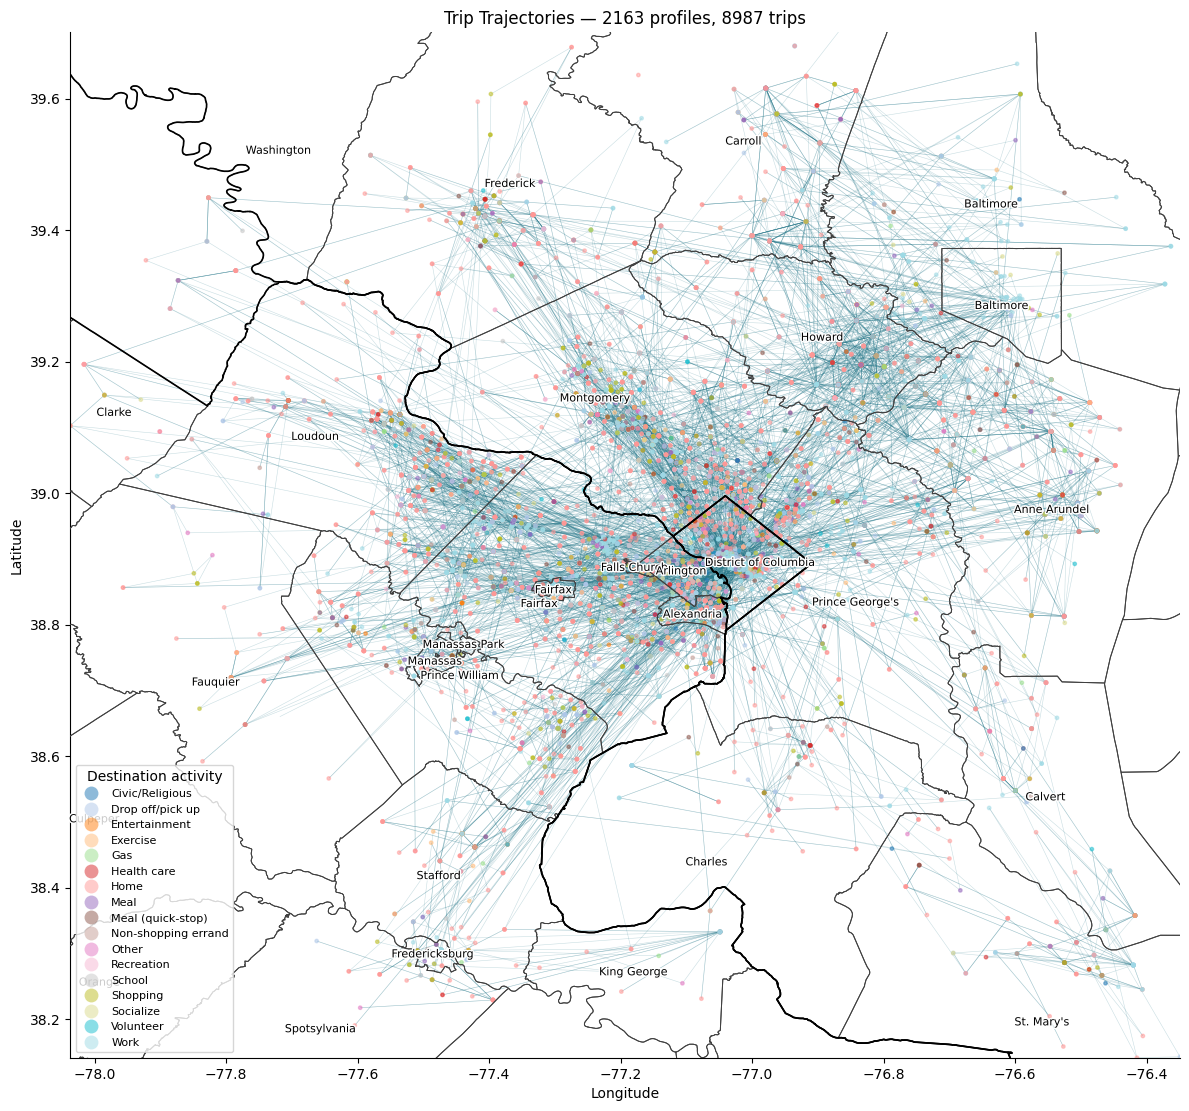

In [69]:
qualifying = [
    profile for profile in filtered_profiles
    if all(trip.origin_coords is not None and trip.dest_coords is not None for trip in profile.trips)
]

lines = [
    LineString([trip.origin_coords, trip.dest_coords])
    for profile in qualifying
    for trip in profile.trips
]

gdf = gpd.GeoDataFrame(geometry = lines, crs = "EPSG:4326")

dest_records = [
    {"activity": trip.dest_activity, "geometry": Point(trip.dest_coords)}
    for profile in qualifying
    for trip in profile.trips
    if trip.dest_activity is not None
]
dest_gdf = gpd.GeoDataFrame(dest_records, crs = "EPSG:4326")

trip_min_x, trip_min_y, trip_max_x, trip_max_y = gdf.total_bounds
pad = 0.5
filter_min_x = trip_min_x - pad
filter_min_y = trip_min_y - pad
filter_max_x = trip_max_x + pad
filter_max_y = trip_max_y + pad

counties_view = counties_gdf.cx[filter_min_x:filter_max_x, filter_min_y:filter_max_y]
states_view = states_gdf.cx[filter_min_x:filter_max_x, filter_min_y:filter_max_y]
dest_view = dest_gdf.cx[filter_min_x:filter_max_x, filter_min_y:filter_max_y]

fig, ax = plt.subplots(figsize = (12, 12))
gdf.plot(ax = ax, color = sns.color_palette("crest")[3], linewidth = 0.4, alpha = 0.25, zorder = 1)
dest_view.plot(
    ax = ax,
    column = "activity",
    categorical = True,
    cmap = "tab20",
    markersize = 6,
    alpha = 0.5,
    legend = True,
    legend_kwds = {"loc": "lower left", "fontsize": 8, "title": "Destination activity"},
    zorder = 2
)
counties_view.boundary.plot(ax = ax, color = "#404040", linewidth = 0.7, zorder = 3)
states_view.boundary.plot(ax = ax, color = "black", linewidth = 1.2, zorder = 4)
for _, county_row in counties_view.iterrows():
    point = county_row.geometry.representative_point()
    ax.annotate(
        county_row["NAME"],
        xy = (point.x, point.y),
        ha = "center",
        va = "center",
        fontsize = 8,
        color = "black",
        zorder = 5,
        path_effects = [pe.withStroke(linewidth = 2, foreground = "white")]
    )

ax.set_xlim(trip_min_x, trip_max_x)
ax.set_ylim(trip_min_y, trip_max_y)
ax.set_aspect("equal")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Trip Trajectories — {len(qualifying)} profiles, {len(lines)} trips")
sns.despine()
plt.tight_layout()
plt.show()